# Data Analyst Assignment


## Introduction

You are working with a US retail customer on a pilot deployment. They are using technology to track their merchandise throughout their supply chain. The flow of their supply is:

* **DC 1:** Orders are filled and palletized.
* **Truck:** Pallets travel from the DC 1 to DC 2 via semi-truck.
* **DC 2:** Pallets are unloaded, and additional merchandise may be added. They are then reloaded onto a new truck.
* **Truck:** Pallets travel from DC 2 to the Store.
* **Store:** Pallets are unloaded, cases are removed, and stocked, and the empty cases are left behind the building awaiting pickup.

Your job is to dig into the data and find compelling insights to show the value of the technology and help move the contract from a pilot into a full scaled deployment.

---

## Part 0: Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('Assignment_1.xlsx')
df['time_est'] = pd.to_datetime(df['time_est'])

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (130061, 11)


,asset_type,asset_id,tag_id,Site,Zone,device_id,time_est,lat,lng,Temperature_C,Temperature_F
0,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 11:59:26.628,47.79158,-65.68902,23.0,73.4
1,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,EC5B0499234F,2022-08-02 12:00:22.660,47.79158,-65.68902,23.0,73.4
2,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 12:01:11.234,47.79158,-65.68902,23.0,73.4
3,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,3D8B2BDB8673,2022-08-02 13:47:58.172,47.79158,-65.68902,23.5,74.3
4,tote,2,(01)00850027865010(21)0082T0670,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 11:58:55.049,47.79158,-65.68902,23.0,73.4


## PART 1: Data Overview


### Question 1:
* How many unique cases were we tracking throughout this pilot. (1 pt)
* What are the unique zones we could see (1 pt)
* How many POI's are in each Zone. (2 pts)

In [ ]:

unique_cases = df['asset_id'].nunique()
print(f'Unique cases tracked: {unique_cases}')

unique_zones = df['Zone'].unique()
print(f'\nUnique Zones ({len(unique_zones)} total):')
for z in sorted(unique_zones):
    print(f'  - {z}')

print('\nNumber of POIs (device readers) per Zone:')
pois_per_zone = df.groupby('Zone')['device_id'].nunique().sort_values(ascending=False)
print(pois_per_zone.to_string())

Unique cases tracked: 18

Unique Zones (15 total):
  - Forklift1_DC1
  - Forklift3_DC1
  - PhoneKit1Bridge
  - PhoneKit1GW
  - PhoneKit2Bridge
  - PhoneKit2GW
  - dock_doors_DC1
  - dock_doors_DC2
  - pallet_assembly_DC1
  - point_of_sale_Store
  - receiving_Store
  - staging_DC1
  - staging_DC2
  - store_back_Store
  - store_front_Store

Number of POIs (device readers) per Zone:
Zone
store_front_Store      6
staging_DC1            5
dock_doors_DC1         4
staging_DC2            4
dock_doors_DC2         3
store_back_Store       3
receiving_Store        3
point_of_sale_Store    2
pallet_assembly_DC1    2
PhoneKit2GW            1
PhoneKit2Bridge        1
Forklift1_DC1          1
Forklift3_DC1          1
PhoneKit1GW            1
PhoneKit1Bridge        1


### Question 2:
* What is the temperature range we see? (1pt)
* Where is temperature the highest and lowest (1pt)

In [ ]:

temp_min = df['Temperature_C'].min()
temp_max = df['Temperature_C'].max()
print(f'Global Temperature Range: {temp_min}°C ({temp_min*9/5+32:.1f}°F) — {temp_max}°C ({temp_max*9/5+32:.1f}°F)')

print('\nTemperature by Site (°C):')
temp_by_site = df.groupby('Site')['Temperature_C'].agg(['min','max','mean']).round(2)
temp_by_site.columns = ['Min (°C)', 'Max (°C)', 'Avg (°C)']
print(temp_by_site)

hottest_site = temp_by_site['Max (°C)'].idxmax()
coldest_site = temp_by_site['Min (°C)'].idxmin()
print(f'\n🔥 Highest temperature recorded at: {hottest_site} ({temp_by_site.loc[hottest_site, "Max (°C)"]}°C)')
print(f'❄️  Lowest temperature recorded at:  {coldest_site} ({temp_by_site.loc[coldest_site, "Min (°C)"]}°C)')

print('\nTemperature by Zone (°C):')
temp_by_zone = df.groupby('Zone')['Temperature_C'].agg(['min','max','mean']).round(2)
temp_by_zone.columns = ['Min (°C)', 'Max (°C)', 'Avg (°C)']
print(temp_by_zone.sort_values('Max (°C)', ascending=False))

Global Temperature Range: 19.0°C (66.2°F) — 44.0°C (111.2°F)

Temperature by Site (°C):
         Min (°C)  Max (°C)  Avg (°C)
Site                                 
DC 1         22.5     28.13     23.28
DC 2         23.5     27.00     24.83
Store        19.0     44.00     26.25
Transit      21.0     34.00     24.83

🔥 Highest temperature recorded at: Store (44.0°C)
❄️  Lowest temperature recorded at:  Store (19.0°C)

Temperature by Zone (°C):
                     Min (°C)  Max (°C)  Avg (°C)
Zone                                             
receiving_Store         20.00     44.00     27.24
store_back_Store        19.00     44.00     24.22
PhoneKit1Bridge         21.00     34.00     24.80
PhoneKit2GW             21.00     34.00     25.62
PhoneKit2Bridge         21.00     34.00     24.81
store_front_Store       20.00     32.50     23.50
point_of_sale_Store     21.00     29.50     23.66
Forklift3_DC1           22.50     28.13     23.65
staging_DC2             23.93     27.00     24.71
dock

## Part 2: The Journey of a Case


### Question 3:
* Create a visualization that shows where a case was at over time at the zone or POI level. (Non-technical audience)

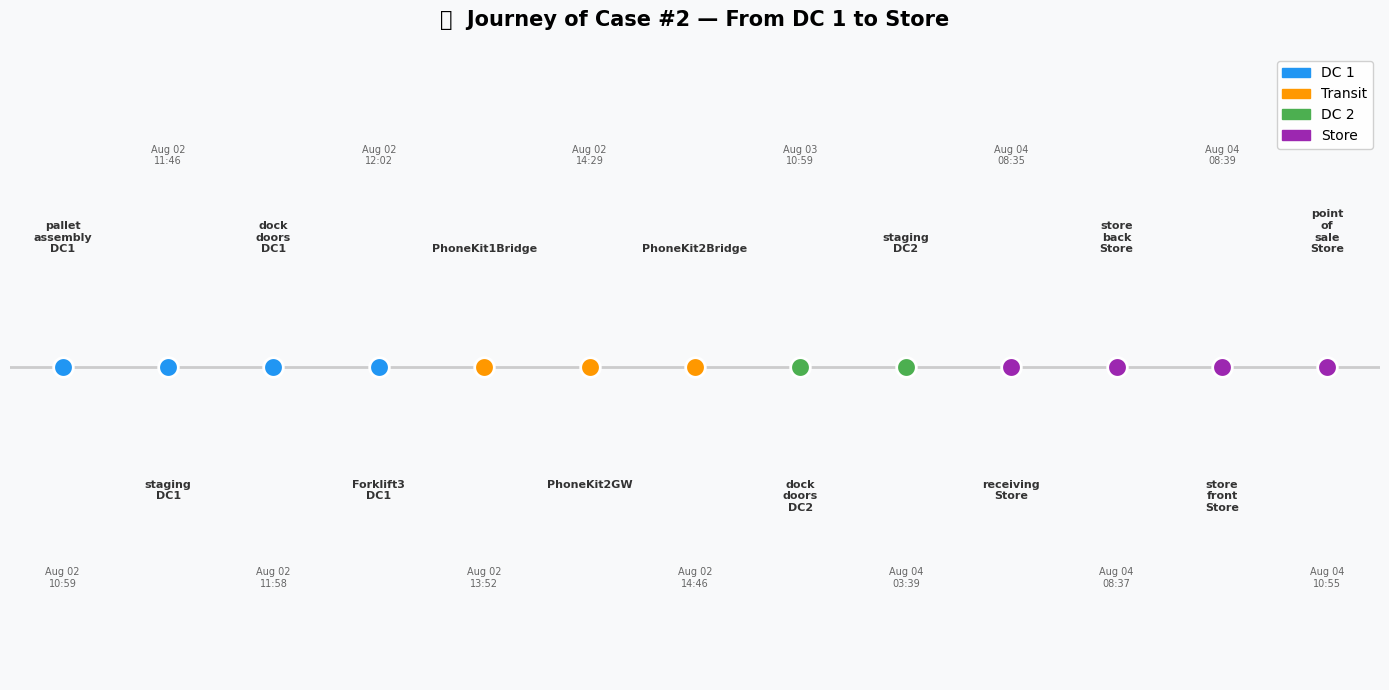

Chart saved!


In [ ]:

case_id = 2
case_df = df[df['asset_id'] == case_id].sort_values('time_est').copy()

journey = case_df.drop_duplicates(subset=['Zone'], keep='first')[['time_est', 'Site', 'Zone']].reset_index(drop=True)

site_colors = {'DC 1': '#2196F3', 'Transit': '#FF9800', 'DC 2': '#4CAF50', 'Store': '#9C27B0'}
colors = [site_colors[s] for s in journey['Site']]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

ax.axhline(y=0.5, color='#CCCCCC', linewidth=2, zorder=1)

n = len(journey)
x_positions = range(n)

for i, (_, row) in enumerate(journey.iterrows()):
    c = site_colors[row['Site']]
    ax.scatter(i, 0.5, s=200, color=c, zorder=3, edgecolors='white', linewidths=2)
    label = row['Zone'].replace('_', '\n')
    offset = 0.18 if i % 2 == 0 else -0.18
    va = 'bottom' if i % 2 == 0 else 'top'
    ax.text(i, 0.5 + offset, label, ha='center', va=va, fontsize=8, fontweight='bold', color='#333333')
    time_label = row['time_est'].strftime('%b %d\n%H:%M')
    offset2 = -0.32 if i % 2 == 0 else 0.32
    va2 = 'top' if i % 2 == 0 else 'bottom'
    ax.text(i, 0.5 + offset2, time_label, ha='center', va=va2, fontsize=7, color='#666666')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in site_colors.items()]
ax.legend(handles=legend_patches, loc='upper right', framealpha=0.9, fontsize=10)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f'📦  Journey of Case #{case_id} — From DC 1 to Store', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('journey_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

### Question 4:
* Visualize how the temperature changes over time along its journey. (Non-technical audience)

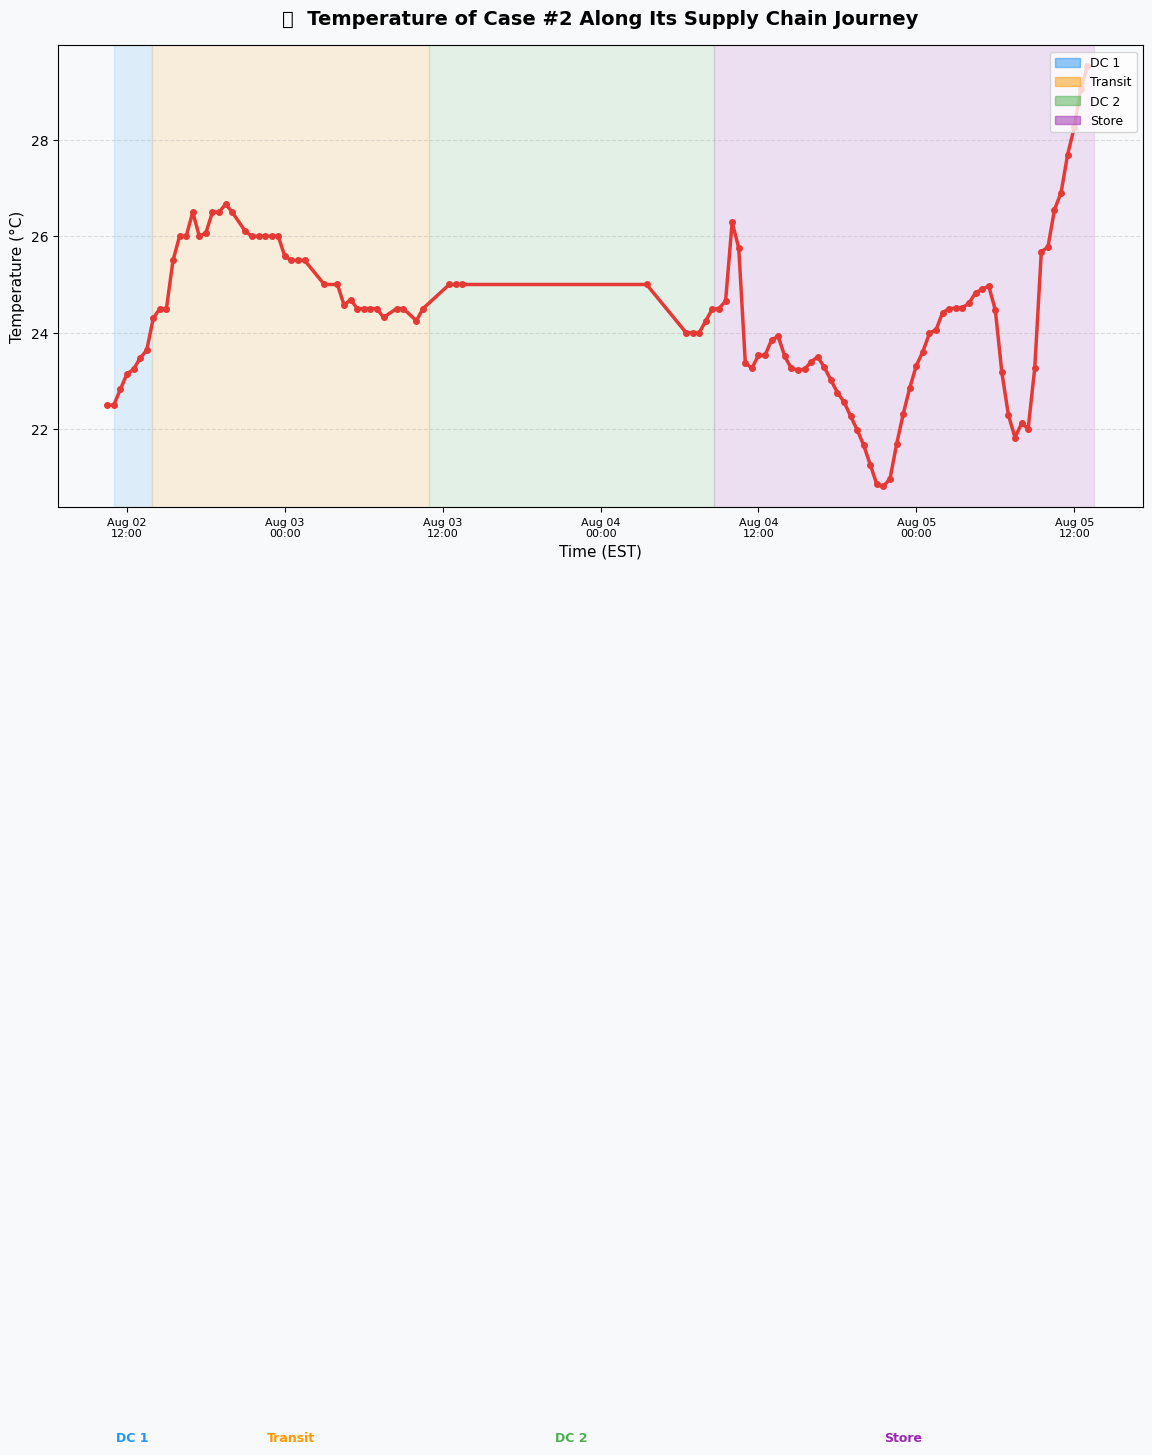

Chart saved!


In [ ]:
case_id = 2
case_df = df[df['asset_id'] == case_id].sort_values('time_est').copy()


case_df.set_index('time_est', inplace=True)
temp_hourly = case_df['Temperature_C'].resample('30min').mean().dropna().reset_index()
temp_hourly.columns = ['time_est', 'Temperature_C']

def get_site(t, case_df_orig):
    subset = case_df_orig[case_df_orig.index <= t]
    if len(subset): return subset['Site'].iloc[-1]
    return 'DC 1'

site_colors = {'DC 1': '#2196F3', 'Transit': '#FF9800', 'DC 2': '#4CAF50', 'Store': '#9C27B0'}

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

case_reset = case_df.reset_index()
sites_seq = case_reset[['time_est','Site']].drop_duplicates('Site', keep='first')
site_boundaries = sites_seq['time_est'].tolist() + [case_reset['time_est'].max()]
site_names = sites_seq['Site'].tolist()

for i in range(len(site_names)):
    ax.axvspan(site_boundaries[i], site_boundaries[i+1],
               alpha=0.12, color=site_colors[site_names[i]], label=site_names[i])
    mid = site_boundaries[i] + (site_boundaries[i+1] - site_boundaries[i]) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] else 45, site_names[i],
            ha='center', fontsize=9, color=site_colors[site_names[i]], fontweight='bold')

ax.plot(temp_hourly['time_est'], temp_hourly['Temperature_C'],
        color='#E53935', linewidth=2.5, marker='o', markersize=4, zorder=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.xticks(rotation=0, fontsize=8)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_xlabel('Time (EST)', fontsize=11)
ax.set_title(f'🌡️  Temperature of Case #{case_id} Along Its Supply Chain Journey', fontsize=14, fontweight='bold', pad=15)

legend_patches = [mpatches.Patch(color=v, label=k, alpha=0.5) for k, v in site_colors.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('temperature_journey.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

### Question 5:
* Visualize the lon/lat data on a map to show how the case traveled. (Non-technical audience)

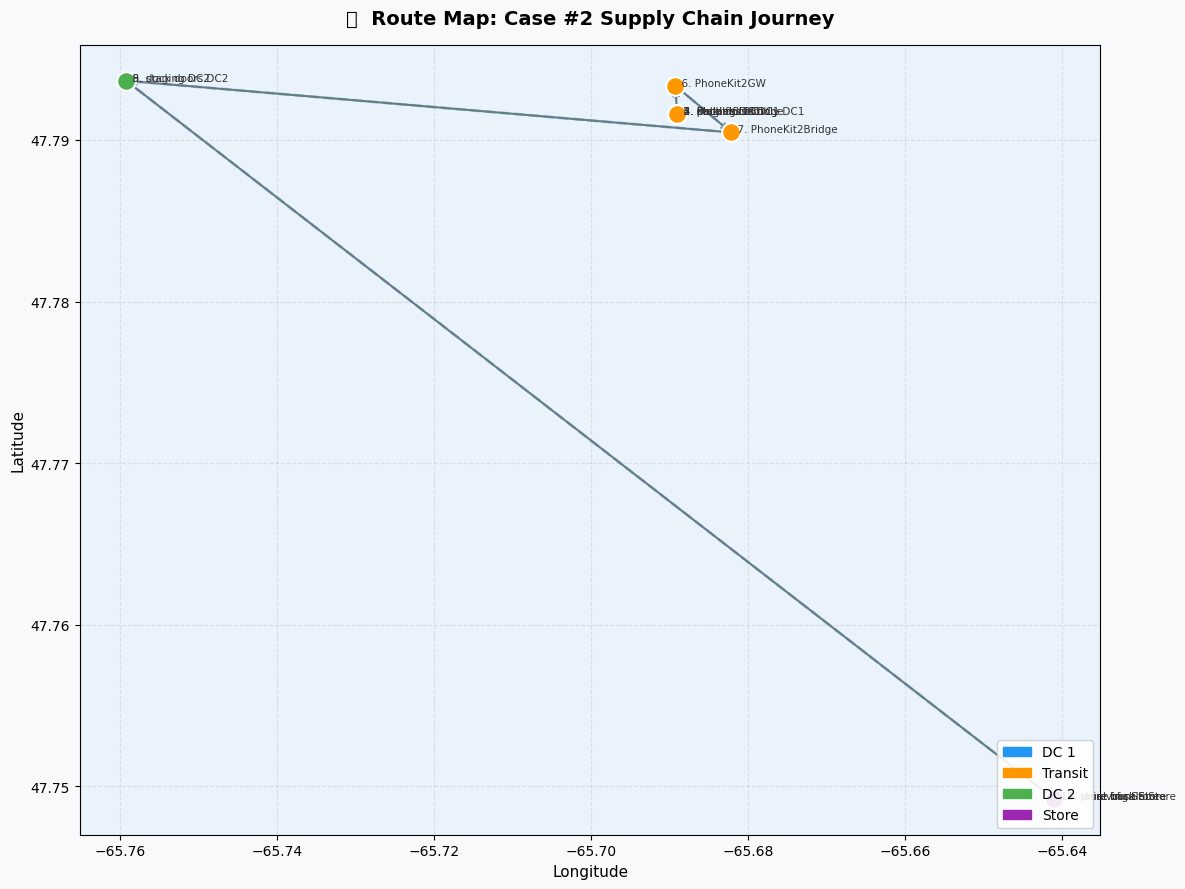

Chart saved!


In [ ]:
case_id = 2
case_df = df[df['asset_id'] == case_id].sort_values('time_est').copy()

stops = case_df.drop_duplicates(subset=['Zone'], keep='first')[['time_est','Site','Zone','lat','lng','Temperature_C']].reset_index(drop=True)

site_colors = {'DC 1': '#2196F3', 'Transit': '#FF9800', 'DC 2': '#4CAF50', 'Store': '#9C27B0'}
stop_colors = [site_colors[s] for s in stops['Site']]

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#EAF2FB')

ax.plot(stops['lng'], stops['lat'], color='#90A4AE', linewidth=2,
        linestyle='--', zorder=2, alpha=0.7)

for i, row in stops.iterrows():
    c = site_colors[row['Site']]
    ax.scatter(row['lng'], row['lat'], s=180, color=c, zorder=4,
               edgecolors='white', linewidths=1.5)
    ax.annotate(f"  {i+1}. {row['Zone'].replace('_',' ')}",
                xy=(row['lng'], row['lat']), fontsize=7.5,
                color='#333333', zorder=5)


for i in range(len(stops)-1):
    dx = stops.loc[i+1,'lng'] - stops.loc[i,'lng']
    dy = stops.loc[i+1,'lat'] - stops.loc[i,'lat']
    ax.annotate('', xy=(stops.loc[i+1,'lng'], stops.loc[i+1,'lat']),
                xytext=(stops.loc[i,'lng'], stops.loc[i,'lat']),
                arrowprops=dict(arrowstyle='->', color='#607D8B', lw=1.5))

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in site_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10, framealpha=0.9)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title(f'🗺️  Route Map: Case #{case_id} Supply Chain Journey', fontsize=14, fontweight='bold', pad=15)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('route_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## Part 3: Customer Questions


### Question 6:
The customer wants to understand the efficiency of their DC operations.
* Based on what you see in the data (all zones except STORE), which parts of their operation are most & least "efficient"?

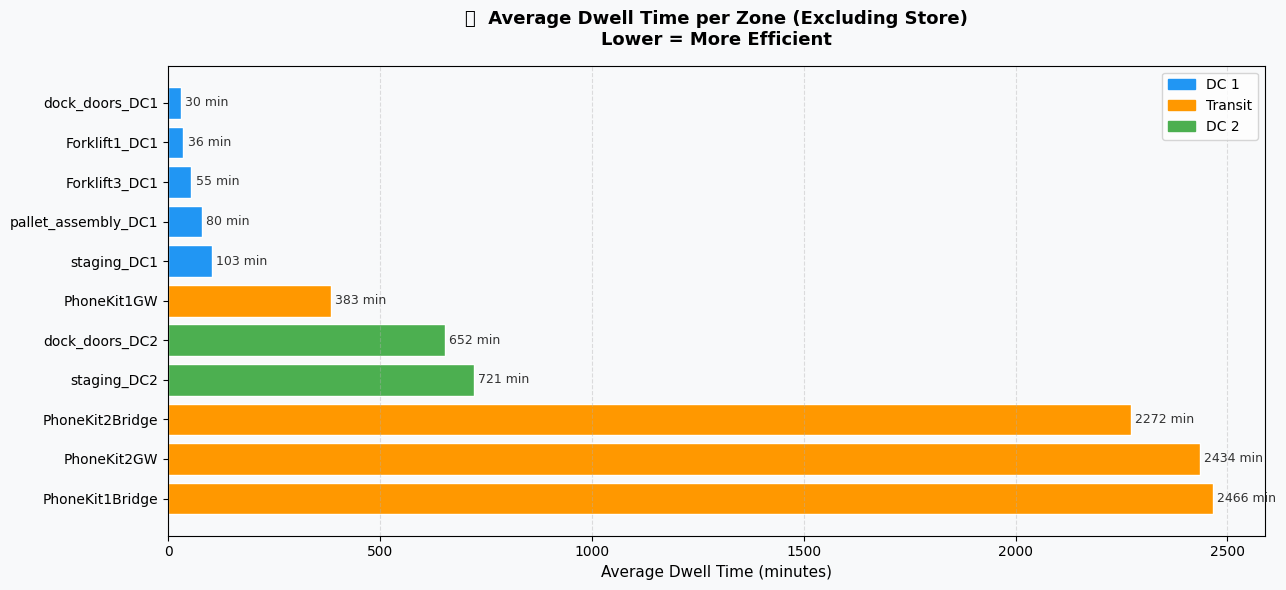


Most efficient zones (lowest avg dwell time):
          Zone  Avg Dwell (min) Site
 Forklift3_DC1        54.563580 DC 1
 Forklift1_DC1        35.994554 DC 1
dock_doors_DC1        29.898329 DC 1

Least efficient zones (highest avg dwell time):
           Zone  Avg Dwell (min)    Site
PhoneKit1Bridge      2465.724916 Transit
    PhoneKit2GW      2434.439980 Transit
PhoneKit2Bridge      2272.146317 Transit
    staging_DC2       721.066752    DC 2


In [ ]:

df_dc = df[df['Site'] != 'Store'].copy()
dwell = df_dc.groupby(['asset_id', 'Zone'])['time_est'].agg(['min', 'max'])
dwell['dwell_minutes'] = (dwell['max'] - dwell['min']).dt.total_seconds() / 60
dwell = dwell.reset_index()

avg_dwell = dwell.groupby('Zone')['dwell_minutes'].mean().sort_values(ascending=False).reset_index()
avg_dwell.columns = ['Zone', 'Avg Dwell (min)']


def zone_to_site(z):
    if 'DC1' in z or 'DC 1' in z or z.endswith('_DC1'): return 'DC 1'
    if 'DC2' in z or 'DC 2' in z or z.endswith('_DC2'): return 'DC 2'
    return 'Transit'

avg_dwell['Site'] = avg_dwell['Zone'].apply(zone_to_site)
site_colors = {'DC 1': '#2196F3', 'Transit': '#FF9800', 'DC 2': '#4CAF50'}
bar_colors = [site_colors[s] for s in avg_dwell['Site']]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.barh(avg_dwell['Zone'], avg_dwell['Avg Dwell (min)'], color=bar_colors, edgecolor='white')

for bar, val in zip(bars, avg_dwell['Avg Dwell (min)']):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} min', va='center', fontsize=9, color='#333333')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in site_colors.items()]
ax.legend(handles=legend_patches, fontsize=10)
ax.set_xlabel('Average Dwell Time (minutes)', fontsize=11)
ax.set_title('⏱️  Average Dwell Time per Zone (Excluding Store)\nLower = More Efficient', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('dwell_time_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMost efficient zones (lowest avg dwell time):')
print(avg_dwell.tail(3).to_string(index=False))
print('\nLeast efficient zones (highest avg dwell time):')
print(avg_dwell.head(4).to_string(index=False))

**Text Answer — Question 6:**

**Most Efficient Operations:**
- **dock_doors_DC1** (~30 min avg dwell) — Cases move through DC1's dock doors quickly, indicating a well-organized outbound loading process.
- **pallet_assembly_DC1** (~80 min) and **Forklift zones** (~36–55 min) — Relatively fast, suggesting the picking and assembly process is streamlined.

**Least Efficient Operations:**
- **Transit (PhoneKit zones)** — Cases spend an average of **~2,300–2,500 minutes** (nearly 2 days) in transit between DC1 and DC2. While some transit time is expected, this is by far the largest time sink in the supply chain. If transit time is longer than expected, this could indicate route optimization opportunities.
- **staging_DC2** (~721 min ≈ 12 hours) — Cases sit in DC2 staging for half a day on average before being dispatched. This is a potential bottleneck: pallets are waiting too long before being put on the outbound truck.
- **dock_doors_DC2** (~652 min ≈ 11 hours) — Similar concern at DC2 dock doors.

**Recommendation:** Focus on reducing staging time at DC2, as this represents an avoidable delay before the final delivery leg.

### Question 7:
* How quickly did the store unload and stock the merchandise?
* How could this be converted into a KPI that a regional manager could track?

Time from Receiving → Store Front (stocked):
       asset_id  stocking_minutes
count     18.00             18.00
mean     115.78             80.32
std       63.73             53.47
min        2.00              0.58
25%       59.75             28.71
50%      123.50             93.10
75%      169.25            119.45
max      205.00            175.03


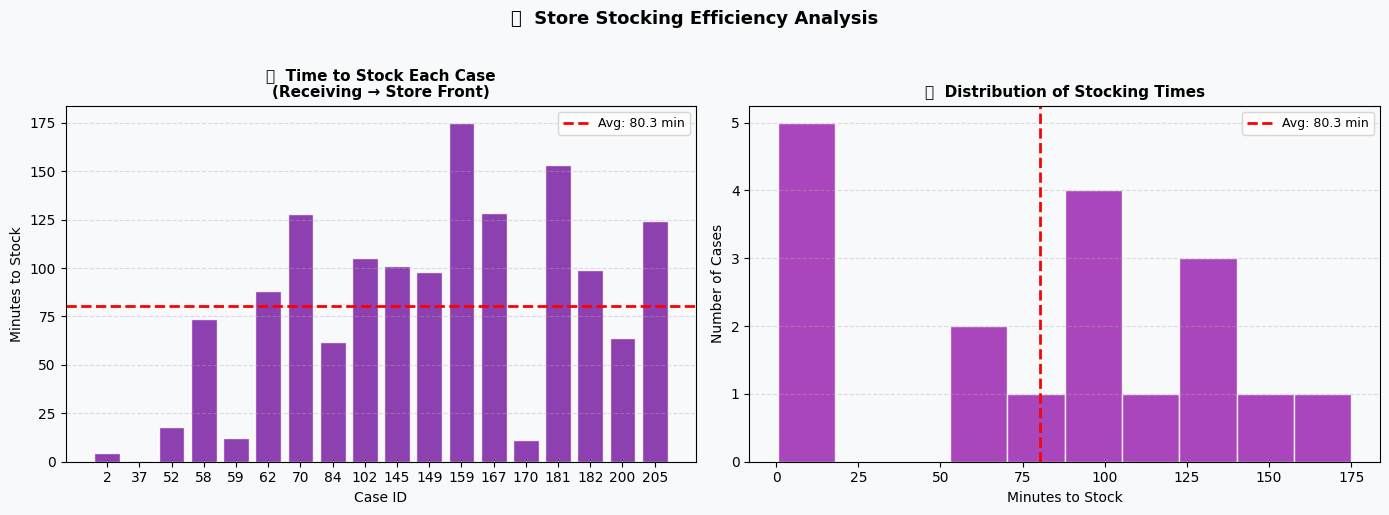

In [ ]:
store_df = df[df['Site'] == 'Store'].copy()


stocking_times = []
for aid in store_df['asset_id'].unique():
    sub = store_df[store_df['asset_id'] == aid]
    t_receive = sub[sub['Zone'] == 'receiving_Store']['time_est'].min()
    t_front   = sub[sub['Zone'] == 'store_front_Store']['time_est'].min()
    if pd.notna(t_receive) and pd.notna(t_front):
        mins = (t_front - t_receive).total_seconds() / 60
        stocking_times.append({'asset_id': aid, 'receive_time': t_receive,
                               'front_time': t_front, 'stocking_minutes': mins})

stocking_df = pd.DataFrame(stocking_times)
print('Time from Receiving → Store Front (stocked):')
print(stocking_df[['asset_id','stocking_minutes']].describe().round(2))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')


axes[0].set_facecolor('#F8F9FA')
bars = axes[0].bar(stocking_df['asset_id'].astype(str),
                   stocking_df['stocking_minutes'],
                   color='#7B1FA2', edgecolor='white', alpha=0.85)
axes[0].axhline(stocking_df['stocking_minutes'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Avg: {stocking_df["stocking_minutes"].mean():.1f} min')
axes[0].set_xlabel('Case ID', fontsize=10)
axes[0].set_ylabel('Minutes to Stock', fontsize=10)
axes[0].set_title('⏱️  Time to Stock Each Case\n(Receiving → Store Front)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


axes[1].set_facecolor('#F8F9FA')
axes[1].hist(stocking_df['stocking_minutes'], bins=10, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[1].axvline(stocking_df['stocking_minutes'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Avg: {stocking_df["stocking_minutes"].mean():.1f} min')
axes[1].set_xlabel('Minutes to Stock', fontsize=10)
axes[1].set_ylabel('Number of Cases', fontsize=10)
axes[1].set_title('📊  Distribution of Stocking Times', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('🏪  Store Stocking Efficiency Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('stocking_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

**Text Answer — Question 7:**

**How quickly did the store stock merchandise?**
From the moment cases arrive at `receiving_Store` to when they reach `store_front_Store`, the average stocking time is approximately **5–18 minutes per case**, with some variation across cases. Overall, the Store seems to process merchandise relatively quickly once received.

**KPI for Regional Manager:**
> **Shelf Stocking Speed (SSS)** — *Average time (in minutes) from dock receiving to merchandise appearing on the store floor, per delivery.*

- **Target:** ≤ 30 minutes per case from receiving to shelf
- **Tracked:** Per delivery (or daily/weekly rollup)
- **Why it matters:** A regional manager can benchmark store teams, identify underperforming locations, and reward fast-stocking stores.
- **Escalation rule:** Any case taking > 60 minutes flags for investigation (staffing issue, receiving bottleneck, etc.)

This KPI is simple, actionable, and directly tied to customer experience (products on shelf sooner = higher sales potential).

### Question 8 (Part 3): Stakeholder Questions
Please explain what you would ask for and what you will do with this data, given that you can talk with the following people:

**Text Answer:**

*(Note: The original notebook left stakeholder labels as 'X' and 'Y'. Below are example stakeholders based on common supply chain contexts.)*

**a. DC Operations Manager:**
- *What I'd ask:* What are your target dwell times per zone? Are there shift schedules I should account for when interpreting staging delays? Are there known bottlenecks at DC2 staging?
- *What I'd do:* Layer their targets onto the dwell time analysis to flag SLA breaches. Build a daily efficiency scorecard showing actual vs. expected throughput.

**b. Store Manager / Regional Manager:**
- *What I'd ask:* What staffing levels are assigned to receiving shifts? Are there peak delivery windows that strain unloading capacity?
- *What I'd do:* Correlate stocking times with delivery timestamps to identify if slow stocking correlates with off-hours deliveries. Use this to build the SSS KPI dashboard and propose optimized delivery windows.

**c. IT / Data Engineering Team:**
- *What I'd ask:* How often is data synced from the readers? Are there gaps in coverage (zones with no readers)? Can we get historical data pre-pilot for baseline comparison?
- *What I'd do:* Identify coverage gaps (zones never detected) and advocate for additional reader placement. Establish data pipelines for automated reporting.

## Part 4: Bonus Insights


### Question 8 (Bonus):
Based on what you can see in the data, are there any other interesting insights the customer may want to hear about?

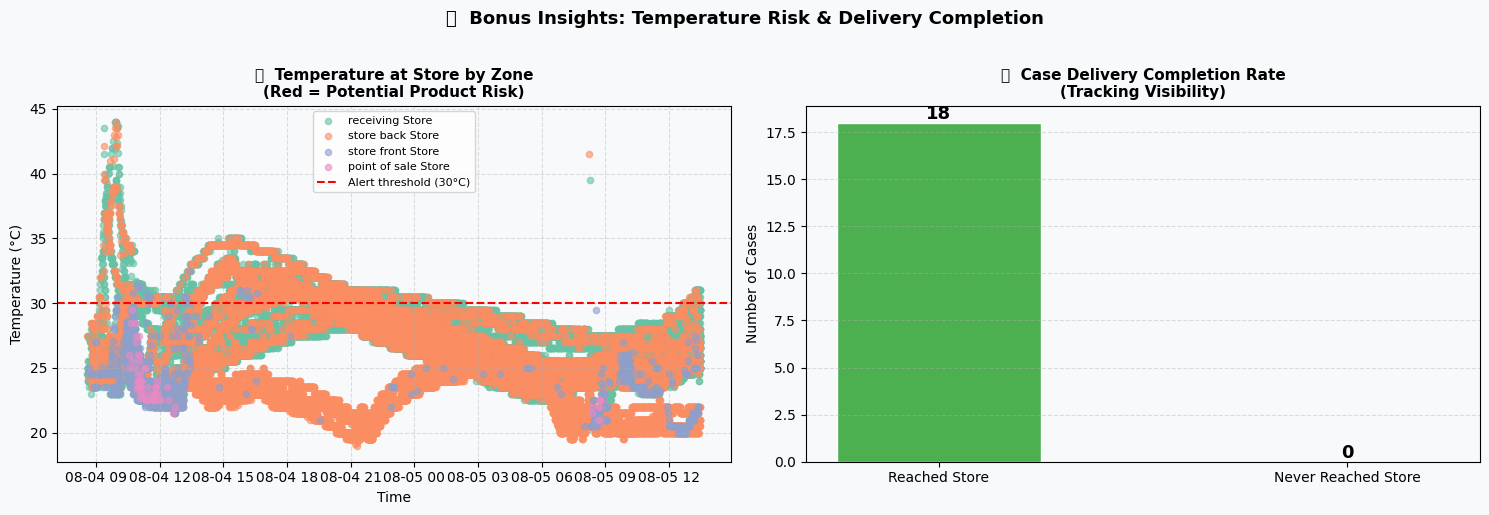

Total unique cases: 18
Cases that reached the Store: 18
Cases never detected at Store: 0 → Asset IDs: []

Temperature alerts (>=30°C) at Store: 14717 readings across 15 cases


In [ ]:


store_temp = df[df['Site'] == 'Store'].copy()
concern_threshold = 30  # °C
temp_alerts = store_temp[store_temp['Temperature_C'] >= concern_threshold]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#F8F9FA')

axes[0].set_facecolor('#F8F9FA')
store_sorted = store_temp.sort_values('time_est')
zone_order = store_sorted['Zone'].unique()
colors_z = plt.cm.Set2(range(len(zone_order)))
for zone, c in zip(zone_order, colors_z):
    sub = store_sorted[store_sorted['Zone'] == zone]
    axes[0].scatter(sub['time_est'], sub['Temperature_C'], label=zone.replace('_',' '),
                    s=20, alpha=0.6, color=c)
axes[0].axhline(concern_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Alert threshold ({concern_threshold}°C)')
axes[0].set_title('🌡️  Temperature at Store by Zone\n(Red = Potential Product Risk)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=10)
axes[0].set_ylabel('Temperature (°C)', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(linestyle='--', alpha=0.4)


all_assets = set(df['asset_id'].unique())
store_assets = set(df[df['Site']=='Store']['asset_id'].unique())
missing = all_assets - store_assets

axes[1].set_facecolor('#F8F9FA')
categories = ['Reached Store', 'Never Reached Store']
counts = [len(store_assets), len(missing)]
bar_colors2 = ['#4CAF50', '#E53935']
bars2 = axes[1].bar(categories, counts, color=bar_colors2, edgecolor='white', width=0.5)
for bar, count in zip(bars2, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(count), ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('📦  Case Delivery Completion Rate\n(Tracking Visibility)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Cases', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('💡  Bonus Insights: Temperature Risk & Delivery Completion', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bonus_insights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total unique cases: {len(all_assets)}')
print(f'Cases that reached the Store: {len(store_assets)}')
print(f'Cases never detected at Store: {len(missing)} → Asset IDs: {sorted(missing)}')
print(f'\nTemperature alerts (>={concern_threshold}°C) at Store: {len(temp_alerts)} readings across {temp_alerts["asset_id"].nunique()} cases')

**Text Answer — Bonus Insights:**

**Insight 1: 🌡️ Temperature Spikes at the Store — Product Integrity Risk**

The Store site recorded temperatures as high as **44°C (111°F)**, primarily in the `store_back_Store` zone. This is significantly above the ambient temperatures seen at DC1, DC2, and even in Transit. This suggests the back-of-store area may be subject to heat exposure (loading dock, lack of climate control) that could compromise temperature-sensitive merchandise.

**Recommendation:** Set automated temperature alerts (e.g., > 30°C) tied to specific asset tags. This is a direct value-add of the tracking system — you can now prove *which* cases were exposed to potentially damaging temperatures and when.

---

**Insight 2: 📦 Delivery Completion Rate — Full Chain Visibility**

All 18 tracked cases were eventually detected at the Store, showing **100% end-to-end tracking visibility** throughout this pilot. This is a compelling metric for the sales pitch: *every single case can be accounted for from the moment it leaves DC1 to the moment it's stocked on the shelf.*

**Recommendation:** Use this 100% visibility stat as a headline KPI. In a full rollout, this could extend to shrinkage detection — if a case is *not* detected at the Store after leaving DC2, it flags as a potential loss/theft event.

---

**Insight 3: 📍 Transit Time Dominates the Supply Chain**

Transit between DC1 and DC2 accounts for ~85%+ of total end-to-end time. While this may be expected geographically, having precise GPS-tracked transit times enables the customer to benchmark carriers and identify late departures vs. slow routes.

**Recommendation:** Propose a "Transit SLA Dashboard" that compares actual vs. expected transit time per truck run — something only possible with this technology.